# Coffe Quality prediction

Our Arabica coffee dataset is highly imbalanced, with 86% Specialty samples and just 13% Below Specialty samples. To properly approach this imbalance, we will implement  two strategies:

 - Handle the data splitting using stratified data splitting, so we have the same ratio in tour training, and testing sets.
 - We employ accuracy metrics that look how well the model handles the minority class, we employ precision, recall and the F1-score




In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import confusion_matrix, precision_recall_curve, classification_report
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_predict

from xgboost import XGBClassifier
from data_train import cup_score_class, train_logistic_regression, threshold_tuning, train_random_forest
from sklearn.metrics import classification_report

RANDOM_STATE = 55
project_root = Path.cwd().parent

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Dataset

We have 1069 coffee samples with 8 selected features: variety, processing_method, moisture, defect counts, color, and altitude.
The target variable is `Total.Cup.Points`.

In [15]:


coffe_data_path = project_root / "data" / "cleaned_coffee_data.csv"   
df = pd.read_csv(coffe_data_path)
X = df.drop(columns= "Total.Cup.Points").copy()
y = df["Total.Cup.Points"].copy()
y = y.apply(cup_score_class)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X.head()


X shape: (1296, 8)
y shape: (1296,)


,altitude_mean_meters,Moisture,Category.One.Defects,Category.Two.Defects,Quakers,Variety,Processing.Method,Color
0,2075.0,0.12,0,0,0.0,NaN,Washed / Wet,Green
1,2075.0,0.12,0,1,0.0,Other,Washed / Wet,Green
2,1700.0,0.00,0,0,0.0,Bourbon,NaN,NaN
3,2000.0,0.11,0,2,0.0,NaN,Natural / Dry,Green
4,2075.0,0.12,0,2,0.0,Other,Washed / Wet,Green


Here, we can clearly see the imbalance of our dataset:

Total.Cup.Points
0    1118
1     178
Name: count, dtype: int64

Percentages:
Total.Cup.Points
0    86.3
1    13.7
Name: proportion, dtype: float64


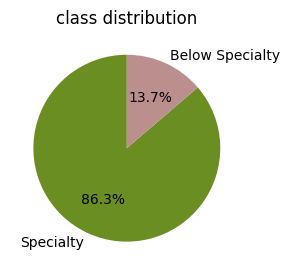

In [16]:
print(y.value_counts())
print(f"\nPercentages:")
print((y.value_counts(normalize=True)*100).round(1))

class_counts = y.value_counts()
plt.figure(figsize=(3, 3))
plt.pie(class_counts,labels=["Specialty", "Below Specialty",], autopct='%1.1f%%', 
    startangle=90,colors = ['olivedrab', 'rosybrown'])
plt.title("class distribution")
plt.tight_layout()
plt.show()

# Splitting the Dataset

We proceed to split the dataset by keeping the same ratio (SPecialty/Below Specialty) in both datasets setting 'stratify =y'

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=RANDOM_STATE, stratify =y
)
print(f"tran sample: {X_train.shape}, test samples: {X_test.shape}")

tran sample: (1036, 8), test samples: (260, 8)


## Feature Engineering

To fill the missing values in some of the features, we employed three strategies. For the numerical features: altitude_mean_meters and Moisture, we replaced the missing values with the median. For the rest of the numerical features that represent the defects, a missing value must imply zero defects, so we replaced them with 0. Finally, for the categorical features, we replaced the missing values with the category 'Unknown' and aplied One-hot enconder to those features with max_categories=10, preventing the model from overfitting. We set this limit because the feature Variety has a high cardinality of 28, and without the limit, the dimentionality of the dataset would increase drastically.

In [18]:

median_num_features = ["altitude_mean_meters", "Moisture"]
zero_num_features = ["Category.One.Defects", "Category.Two.Defects", "Quakers"]
categorical_features = ["Variety", "Processing.Method", "Color"]

median_numerical_pipeline = Pipeline([
    ("impute_median", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])

zero_numerical_pipeline = Pipeline([
    ("impute_zero", SimpleImputer(strategy="constant", fill_value=0)),
    ("scale", StandardScaler()),
])

categorical_pipeline = Pipeline([
    ("impute_unknown", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("onehot", OneHotEncoder(handle_unknown="ignore",sparse_output=False, max_categories=10)),
])

preprocessor = ColumnTransformer([
    ("num_median", median_numerical_pipeline, median_num_features),
    ("num_zero", zero_numerical_pipeline, zero_num_features),
    ("categorical", categorical_pipeline, categorical_features )
])



# Model building and Evaluation

## Logistic Regression 

We start the model training with Logistic Regression. For hyperparameter tuning, we performed a search for the optimal regularization parameter C (the default is set to C=1). 
 
Furthermore, to adress the class imbalance in our dataset, we also tune the classification threshold (moving away from the default 50% probability) to optimize how reliably the model flags a coffee as Below Specialty.


In [19]:
#regularization parameter
param_grid = {'clf__C': [0.001, 0.01, 0.1, 1, 10, 100]}

lr_model, best_lr_grid = train_logistic_regression(preprocessor, X_train, y_train,random_state=RANDOM_STATE,param_grid=param_grid)
print(f"Best grid parameters: {best_lr_grid.best_params_}")

#tuning decision threshold
optimal_threshold = threshold_tuning(lr_model, X_train, y_train, random_state=RANDOM_STATE)
print(f"\n optimal_thershold: {optimal_threshold}\n")
y_test_probs = lr_model.predict_proba(X_test)[:, 1]
y_test_pred_opt = (y_test_probs >= optimal_threshold).astype(int)
print(confusion_matrix(y_test, y_test_pred_opt))
print(classification_report(y_test, y_test_pred_opt, target_names=['Specialty (0)', 'Below Specialty (1)'],digits=3))

Best grid parameters: {'clf__C': 0.01}

 optimal_thershold: 0.5645771560747344

[[202  22]
 [ 24  12]]
                     precision    recall  f1-score   support

      Specialty (0)      0.894     0.902     0.898       224
Below Specialty (1)      0.353     0.333     0.343        36

           accuracy                          0.823       260
          macro avg      0.623     0.618     0.620       260
       weighted avg      0.819     0.823     0.821       260



As expected, the precision for Below Specialty is quite low, meaning, when the model predicts a coffee is below specialty, it is right only 35% of the time, while the remaining 65% of those predictions are false positives that missclasify actual specialty coffee.

From hyperparameter tuning, the optimal regularization parameter has being reduced to  C=0.01, introducing a stronger regularization to overcome overfitting.

To evaluate and compare our different ML models, we will use the macro average F1-score, which treats both classes equally.


# Random Forest Classifier



In [21]:

param_grid = {
        "clf__n_estimators": [100, 200, 300, 400],
        "clf__max_features": ['sqrt', 0.3, 0.5, 1.0],
        "clf__min_samples_leaf": [2, 3, 5, 7],
        "clf__max_depth": [None, 2, 3],
    }

rf_forest_model, rf_grid_search = train_random_forest(preprocessor, X_train, y_train, random_state=RANDOM_STATE, class_weight = 'balanced',param_grid=param_grid)
print(f"Best grid parameters: {rf_grid_search.best_params_}")

optimal_threshold = threshold_tuning(rf_forest_model, X_train, y_train, random_state=RANDOM_STATE)
print(optimal_threshold)
y_test_probs = rf_forest_model.predict_proba(X_test)[:, 1]
y_test_pred_opt = (y_test_probs >= optimal_threshold).astype(int)
print(confusion_matrix(y_test, y_test_pred_opt))
print(classification_report(y_test, y_test_pred_opt, digits=3))


Fitting 5 folds for each of 192 candidates, totalling 960 fits
Best grid parameters: {'clf__max_depth': None, 'clf__max_features': 0.3, 'clf__min_samples_leaf': 5, 'clf__n_estimators': 200}
0.5750061027963634
[[207  17]
 [ 25  11]]
              precision    recall  f1-score   support

           0      0.892     0.924     0.908       224
           1      0.393     0.306     0.344        36

    accuracy                          0.838       260
   macro avg      0.643     0.615     0.626       260
weighted avg      0.823     0.838     0.830       260



# XGBoost Classifier

We test XGBoost as it gives preference to the training examples that did not do well.

In [24]:
num_zeros = np.sum(y_train == 0)
num_ones = np.sum(y_train == 1)
optimal_scale = num_zeros / num_ones


pipe = Pipeline([
        ("pre", preprocessor),
        ("clf", XGBClassifier(
    n_estimators=300,
    scale_pos_weight=optimal_scale, 
    random_state=RANDOM_STATE,
    n_jobs=-1)),
    ])

param_grid = {
    'clf__learning_rate': [0.01, 0.05, 0.1],
    'clf__max_depth': [3, 5, 7, 8],
    'clf__min_child_weight': [1, 3, 5],
    'clf__gamma' : [0, 0.01, 0.5],
    'clf__subsample': [ 0.6, 0.7, 0.8],
    'clf__colsample_bytree': [0.5, 0.7, 0.9]
}


grid_search_xgb = GridSearchCV(
    pipe,
    param_grid=param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='average_precision',
    n_jobs=-1
)


grid_search_xgb.fit(X_train, y_train)

print(f"Best XGBoost Parameters: {grid_search_xgb.best_params_}")
best_xgb = grid_search_xgb.best_estimator_

y_pred_tuned_xgb = best_xgb.predict(X_test)
print(confusion_matrix(y_test, y_pred_tuned_xgb))
print(classification_report(y_test, y_pred_tuned_xgb, target_names=['Specialty (0)', 'Below Specialty (1)'], digits=3))

Best XGBoost Parameters: {'clf__colsample_bytree': 0.5, 'clf__gamma': 0.5, 'clf__learning_rate': 0.01, 'clf__max_depth': 8, 'clf__min_child_weight': 3, 'clf__subsample': 0.6}
[[186  38]
 [ 13  23]]
                     precision    recall  f1-score   support

      Specialty (0)      0.935     0.830     0.879       224
Below Specialty (1)      0.377     0.639     0.474        36

           accuracy                          0.804       260
          macro avg      0.656     0.735     0.677       260
       weighted avg      0.857     0.804     0.823       260

